In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def sobel_operators(mu=0, sigma=1):
    sobel_operator_x = np.array([[-norm.pdf(1, loc=mu, scale=sigma), 0, norm.pdf(1, loc=mu, scale=sigma)], [-norm.pdf(0, loc=mu, scale=sigma), 0, norm.pdf(0, loc=mu, scale=sigma)], [-norm.pdf(-1, loc=mu, scale=sigma), 0, norm.pdf(-1, loc=mu, scale=sigma)]])
    sobel_operator_y = np.array([[-norm.pdf(1, loc=mu, scale=sigma), -norm.pdf(0, loc=mu, scale=sigma), -norm.pdf(-1, loc=mu, scale=sigma)], [0, 0, 0], [norm.pdf(1, loc=mu, scale=sigma), norm.pdf(0, loc=mu, scale=sigma), norm.pdf(-1, loc=mu, scale=sigma)]])
    return sobel_operator_x, sobel_operator_y

def convolution(image, kernel):
    r, c = image.shape
    output = np.zeros((r, c))
    pad_r = kernel.shape[0] // 2
    pad_c = kernel.shape[1] // 2
    pad_img = np.zeros((r + 2*pad_r, c + 2*pad_c))
    pad_img[pad_r:r+pad_r, pad_c:c+pad_c] = image
    kernel = np.flipud(np.fliplr(kernel))
    for row in range(pad_r, r+pad_r):
        for col in range(pad_c, c+pad_c):
            patch = pad_img[row-pad_r:row+pad_r+1, col-pad_c:col+pad_c+1]
            output[row-pad_r, col-pad_c] = np.dot(patch.flatten(), kernel.flatten())
    return output

### 1. DoG-based Keypoint Detection

In [3]:
img1 = cv2.imread('..\Dataset\church_002.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('..\Dataset\church_003.png', cv2.IMREAD_GRAYSCALE)

img1 = img1.astype(np.float64) / 255.0
img2 = img2.astype(np.float64) / 255.0

#### 1.1 Generate Gaussian Pyramid


In [4]:
def generate_gaussian_pyramid(image, num_octaves=3, s=3, sigma_0=0.6):
    k = 2 ** (1 / s)
    pyramid = []
    current_image = image.copy()
    
    for octave in range(num_octaves):
        octave_images = []
        for i in range(s + 3):
            sigma = (sigma_0 * (k ** i)) if octave == 0 and i == 0 else (sigma_0 * (k ** i))
            blurred = cv2.GaussianBlur(current_image, (0, 0), sigmaX=sigma, sigmaY=sigma)
            octave_images.append(blurred)
        pyramid.append(octave_images)
        current_image = octave_images[-3][::2, ::2]
        
    return pyramid



#### 1.2 Generate DoG Pyramid


In [5]:
def generate_dog_pyramid(gaussian_pyramid):
    dog_pyramid = []
    for octave_images in gaussian_pyramid:
        octave_dogs = []
        for i in range(len(octave_images) - 1):
            dog = octave_images[i+1] - octave_images[i]
            octave_dogs.append(dog)
        dog_pyramid.append(octave_dogs)
    return dog_pyramid



#### 1.3 Detect Keypoints


In [6]:
def detect_keypoints(dog_pyramid, s=3, sigma_0=0.6, contrast_threshold=0.01):
    k = 2 ** (1 / s)
    keypoints = []
    
    for octave_idx, octave_dogs in enumerate(dog_pyramid):
        for i in range(1, len(octave_dogs) - 1):
            bottom = octave_dogs[i-1]
            middle = octave_dogs[i]
            top = octave_dogs[i+1]
            
            h, w = middle.shape
            
            for y in range(1, h - 1):
                for x in range(1, w - 1):
                    val = middle[y, x]
                    
                    if abs(val) < contrast_threshold:
                        continue
                        
                    patch_bottom = bottom[y-1:y+2, x-1:x+2]
                    patch_middle = middle[y-1:y+2, x-1:x+2]
                    patch_top = top[y-1:y+2, x-1:x+2]
                    
                    is_max = (val >= patch_bottom).all() and (val >= patch_middle).all() and (val >= patch_top).all()
                    is_min = (val <= patch_bottom).all() and (val <= patch_middle).all() and (val <= patch_top).all()
                    
                    if is_max or is_min:
                        scale = sigma_0 * (k ** i) * (2 ** octave_idx)
                        x_orig = x * (2 ** octave_idx)
                        y_orig = y * (2 ** octave_idx)
                        keypoints.append((x_orig, y_orig, scale, octave_idx, i))
                        
    return keypoints



#### 1.4 Visualize Pyramids and Keypoints


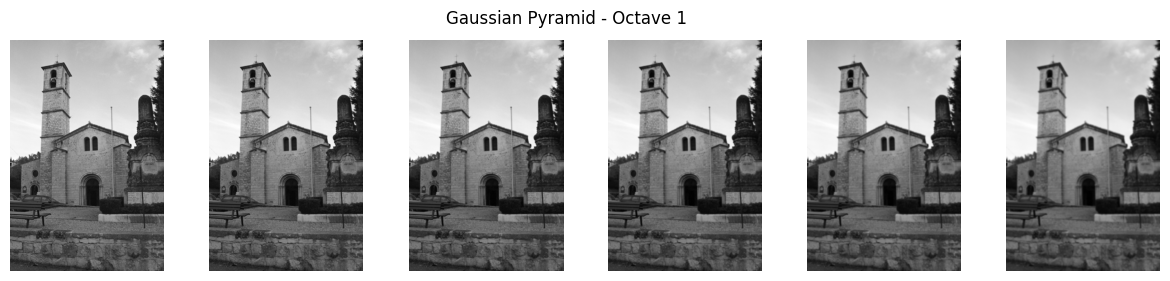

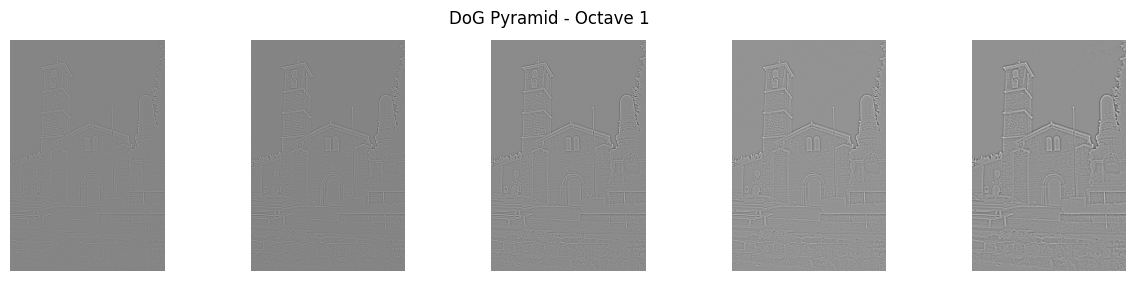

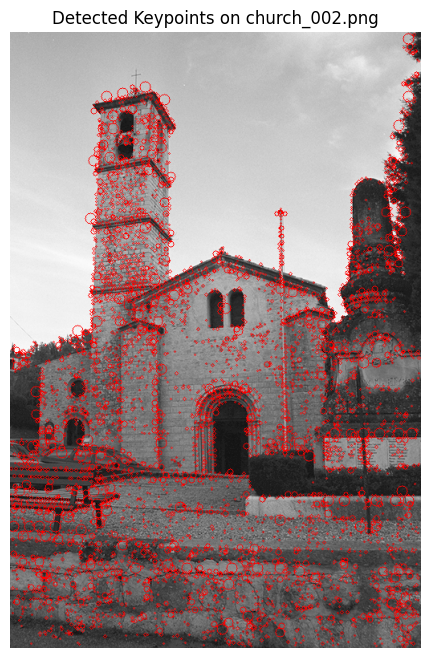

In [7]:
pyr1 = generate_gaussian_pyramid(img1)
dog_pyr1 = generate_dog_pyramid(pyr1)
kps1 = detect_keypoints(dog_pyr1)

plt.figure(figsize=(15, 3))
for i in range(len(pyr1[0])):
    plt.subplot(1, len(pyr1[0]), i+1)
    plt.imshow(pyr1[0][i], cmap='gray')
    plt.axis('off')
plt.suptitle("Gaussian Pyramid - Octave 1")
plt.show()

plt.figure(figsize=(15, 3))
for i in range(len(dog_pyr1[0])):
    plt.subplot(1, len(dog_pyr1[0]), i+1)
    plt.imshow(dog_pyr1[0][i], cmap='gray')
    plt.axis('off')
plt.suptitle("DoG Pyramid - Octave 1")
plt.show()

img1_vis = (cv2.normalize(img1, None, 0, 255, cv2.NORM_MINMAX)).astype(np.uint8)
img1_vis = cv2.cvtColor(img1_vis, cv2.COLOR_GRAY2RGB)

for kp in kps1:
    x, y, scale = int(kp[0]), int(kp[1]), kp[2]
    radius = max(1, int(np.round(scale * 1.5)))
    cv2.circle(img1_vis, (x, y), radius, (255, 0, 0), 1)

plt.figure(figsize=(8, 8))
plt.imshow(img1_vis)
plt.title("Detected Keypoints on church_002.png")
plt.axis('off')
plt.show()

### 2. Basic Descriptor Construction

In [ ]:
sobel_x, sobel_y = sobel_operators(sigma=1.0)

grad_x = convolution(img1, sobel_x)
grad_y = convolution(img1, sobel_y)

mag = np.sqrt(grad_x**2 + grad_y**2)

ori = np.degrees(np.arctan2(grad_y, grad_x))
ori[ori < 0] += 360

#### 2.1 Compute SIFT Descriptor


In [9]:
def compute_descriptor(mag, ori, x, y):

    x = int(x)
    y = int(y)

    patch_size = 16
    half_patch = 8

    if (y-half_patch < 0 or y+half_patch >= mag.shape[0] or
        x-half_patch < 0 or x+half_patch >= mag.shape[1]):
        return None

    patch_mag = mag[y-half_patch:y+half_patch, x-half_patch:x+half_patch]
    patch_ori = ori[y-half_patch:y+half_patch, x-half_patch:x+half_patch]

    descriptor = np.zeros((4,4,8))

    for r in range(4):
        for c in range(4):

            cell_mag = patch_mag[r*4:(r+1)*4, c*4:(c+1)*4]
            cell_ori = patch_ori[r*4:(r+1)*4, c*4:(c+1)*4]

            for i in range(4):
                for j in range(4):

                    bin_idx = int(cell_ori[i,j] // 45) % 8
                    descriptor[r,c,bin_idx] += cell_mag[i,j]

    descriptor = descriptor.flatten()

    norm = np.linalg.norm(descriptor)
    if norm > 0:
        descriptor /= norm

    descriptor = np.clip(descriptor, 0, 0.2)

    norm = np.linalg.norm(descriptor)
    if norm > 0:
        descriptor /= norm

    return descriptor




#### 2.2 Calculate Descriptors for Keypoints


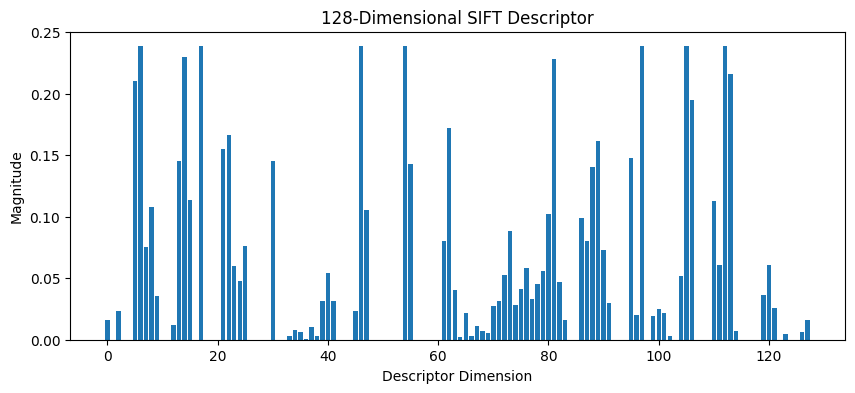

In [10]:
descriptors1 = []
valid_kps1 = []

for kp in kps1:

    desc = compute_descriptor(mag, ori, kp[0], kp[1])

    if desc is not None:
        descriptors1.append(desc)
        valid_kps1.append(kp)

descriptors1 = np.array(descriptors1)


plt.figure(figsize=(10,4))

if descriptors1.shape[0] > 0:
    plt.bar(range(128), descriptors1[0])
    plt.title("128-Dimensional SIFT Descriptor")
    plt.xlabel("Descriptor Dimension")
    plt.ylabel("Magnitude")

plt.show()

### 3. Descriptor Matching

In [11]:
pyr2 = generate_gaussian_pyramid(img2)
dog_pyr2 = generate_dog_pyramid(pyr2)
kps2 = detect_keypoints(dog_pyr2)


sobel_x, sobel_y = sobel_operators(sigma=1.0)

grad_x2 = convolution(img2, sobel_x)
grad_y2 = convolution(img2, sobel_y)

mag2 = np.sqrt(grad_x2**2 + grad_y2**2)

ori2 = np.degrees(np.arctan2(grad_y2, grad_x2))
ori2[ori2 < 0] += 360


descriptors2 = []
valid_kps2 = []

for kp in kps2:

    desc = compute_descriptor(mag2, ori2, kp[0], kp[1])

    if desc is not None:
        descriptors2.append(desc)
        valid_kps2.append(kp)

descriptors2 = np.array(descriptors2)




#### 3.1 Feature Matching logic


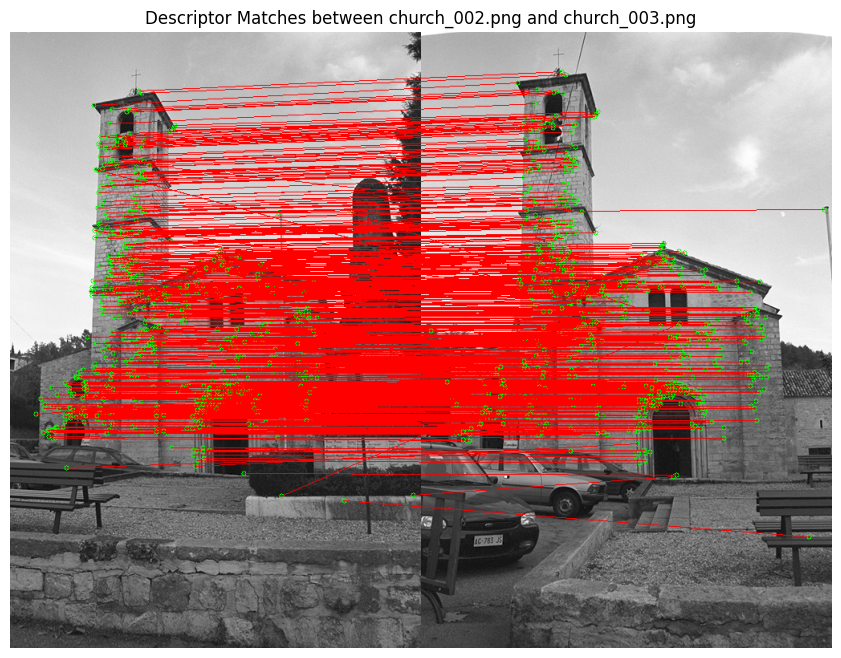

In [12]:
matches = []

for i, d1 in enumerate(descriptors1):

    if descriptors2.shape[0] < 2:
        continue

    distances = np.linalg.norm(descriptors2 - d1, axis=1)

    sorted_indices = np.argsort(distances)

    d_best = distances[sorted_indices[0]]
    d_second = distances[sorted_indices[1]]

    if d_best < 0.75 * d_second:
        matches.append((i, sorted_indices[0]))


img1_vis = (cv2.normalize(img1, None, 0, 255, cv2.NORM_MINMAX)).astype(np.uint8)
img2_vis = (cv2.normalize(img2, None, 0, 255, cv2.NORM_MINMAX)).astype(np.uint8)

h1, w1 = img1_vis.shape
h2, w2 = img2_vis.shape

out_img = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8)

out_img[:h1, :w1] = img1_vis
out_img[:h2, w1:] = img2_vis

out_img = cv2.cvtColor(out_img, cv2.COLOR_GRAY2RGB)


for m in matches:

    kp1 = valid_kps1[m[0]]
    kp2 = valid_kps2[m[1]]

    pt1 = (int(kp1[0]), int(kp1[1]))
    pt2 = (int(kp2[0]) + w1, int(kp2[1]))

    cv2.circle(out_img, pt1, 3, (0,255,0), 1)
    cv2.circle(out_img, pt2, 3, (0,255,0), 1)

    cv2.line(out_img, pt1, pt2, (255,0,0), 1)

plt.figure(figsize=(15,8))
plt.imshow(out_img)
plt.title("Descriptor Matches between church_002.png and church_003.png")
plt.axis("off")
plt.show()

### 4. Effect of Scales per Octave

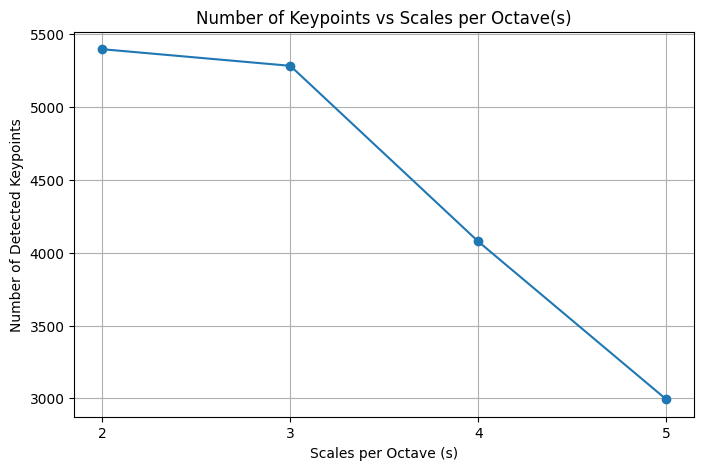

In [13]:
scales = [2, 3, 4, 5]
num_kps = []

for s_val in scales:
    pyr_s = generate_gaussian_pyramid(img1, s=s_val)
    dog_pyr_s = generate_dog_pyramid(pyr_s)
    kps_s = detect_keypoints(dog_pyr_s, s=s_val)
    num_kps.append(len(kps_s))

plt.figure(figsize=(8, 5))
plt.plot(scales, num_kps, marker='o')
plt.title("Number of Keypoints vs Scales per Octave(s)")
plt.xlabel("Scales per Octave (s)")
plt.ylabel("Number of Detected Keypoints")
plt.xticks(scales)
plt.grid(True)
plt.show()

The number of detected keypoints generally increases as the number of scales per octave (s) increases.
With more scales per octave, the scale space is sampled more densely. This means the Difference of Gaussian (DoG)
images capture variations at finer scale increments, providing more opportunities for local extrema to occur
and be detected across the 3D neighborhood.

### 5. Discussion and Analysis


1. Scale Invariance: SIFT achieves robustness to scale changes by identifying keypoints in a continuous scale-space representation (Difference of Gaussian pyramid). By finding stable extrema across both spatial dimensions and scale dimensions simultaneously, SIFT assigns an intrinsic scale to each keypoint. When descriptors are subsequently extracted, they are computed from a local image patch sized proportionally to this intrinsic scale, making the resulting feature representation invariant to the original image's resolution or scale.

2. Rotation Invariance Problem: The currently implemented basic version fails on rotated images because the gradients within the 16x16 patch are computed relative to the fixed horizontal and vertical axes of the image. When the image rotates, the gradient directions shift relative to these axes. To achieve rotation invariance, we must first compute a dominant gradient orientation for the local patch around the keypoint. We would then rotate the descriptor grid (or alternatively, subtract the dominant orientation from all local gradient angles) so that the descriptor is always computed relative to this canonical, local orientation rather than the global image axes.

3. Illumination Invariance: The current normalization to unit length successfully provides robustness against affine illumination changes (multiplicative contrast changes). To further improve robustness to non-linear lighting changes, such as partial camera saturation or heavy specular highlights that cause extremely large gradient components, an additional step can be added: clipping the normalized descriptor values to a maximum threshold (e.g., 0.2). After capping the largest gradients, the entire descriptor vector is re-normalized to unit length. This distributes importance more evenly across the spatial bins and orientations, preventing a single highly illuminated edge from dominating the histogram weighting.